# Strategy Comparison — All Models

Runs every portfolio strategy in a single shared environment and produces unified comparisons.

**Strategies (rolling, realistic — no look-ahead bias):**
Equal Weight · 60/40 Benchmark · Sample Portfolio · Naive RP · ERC RP · Markowitz · Black-Litterman · Factor Investing · FSO (γ=3.0)

**Metrics:** Ann. Return (CAGR), Volatility, Sharpe, Sortino, Max DD, Skewness, Kurtosis, Final Value, Recovery time per crisis

---
### Methodological notes
- **Annualized Return** is computed as geometric CAGR: `(product of (1+r))^(12/T) - 1`. This reflects actual compounded investor wealth.
- **Sortino Ratio** uses the correct downside deviation: `sqrt(mean(min(r - rf, 0)^2)) * sqrt(12)` over the *full* return series. Positive months contribute zero to downside — not filtered out.
- **Naive RP** weights are estimated from the first `LOOKBACK` months only (in-sample inception window), avoiding look-ahead bias. All subsequent months use those fixed weights.
- **ERC RP** weights always sum to 1 (no leverage/vol-targeting scaling). This ensures a fair apples-to-apples comparison with all other unlevered strategies.
- **Markowitz** is constrained to exactly `VOL_TARGET` (10%) annualized volatility at each rebalance. This reflects a risk-budgeted deployment rather than unconstrained MPT. Other strategies (BL, FSO, Factor) are unconstrained — this is an intentional design choice documented here.
- **60/40 Benchmark** uses VEU (Vanguard FTSE All-World ex-US, 60%) and BND (40%). Note: VEU is an international equity proxy, not a US equity proxy. Comparisons to a US-centric 60/40 should account for VEU's underperformance vs US equity over 2010–2025.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.optimize as sco
from sklearn.covariance import LedoitWolf
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

BASE = Path('../../data')
with open('../../markets.json') as f:
    config = json.load(f)

market_name        = list(config['markets'].keys())[0]
initial_investment = config['initial_investment']

LOOKBACK        = 36
REBAL_THRESHOLD = 0.05
VOL_TARGET      = 0.10
CRISES = [
    ('2008-09', '2009-06', 'GFC'),
    ('2020-02', '2020-04', 'COVID'),
    ('2022-01', '2022-12', 'Rate Hikes'),
]

plt.rcParams.update({
    'figure.facecolor': '#F4F7FB', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.color': '#CBD5E0',
    'font.family': 'sans-serif',
})
print(f'Market: {market_name}  |  Initial investment: ${initial_investment:,.0f}')
print(f'Lookback: {LOOKBACK}m  |  Rebal threshold: {REBAL_THRESHOLD*100:.0f}%  |  MPT vol target: {VOL_TARGET*100:.0f}%')

Market: primary_total_market  |  Initial investment: $1,000
Lookback: 36m  |  Rebal threshold: 5%  |  MPT vol target: 10%


In [2]:
returns = pd.read_csv(BASE / f'{market_name}_returns_monthly.csv', index_col=0, parse_dates=True)
assets  = returns.columns.tolist()
N       = len(assets)

rf_data           = pd.read_csv(BASE / 'risk_free_monthly.csv', index_col=0, parse_dates=True)
rf_data           = rf_data.reindex(returns.index, method='ffill')  # align to returns dates
annual_rf_series  = rf_data['rf_annual']
monthly_rf_series = rf_data['rf_monthly']

print(f'Returns : {returns.index[0].date()} -> {returns.index[-1].date()} ({len(returns)} months)')
print(f'Assets  : {assets}')
print(f'RF mean : {annual_rf_series.mean()*100:.3f}% annual (full period)')
returns.describe().round(4)

Returns : 2007-05-01 -> 2025-12-01 (224 months)
Assets  : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
RF mean : 1.415% annual (full period)


,BND,GLD,TIP,TLT,VEU,VGT
count,224.0000,224.0000,224.0000,224.0000,224.0000,224.0000
mean,0.0026,0.0091,0.0030,0.0033,0.0050,0.0141
std,0.0135,0.0490,0.0174,0.0411,0.0520,0.0570
min,-0.0419,-0.1614,-0.0811,-0.1249,-0.2276,-0.1795
25%,-0.0046,-0.0217,-0.0058,-0.0238,-0.0239,-0.0184
50%,0.0026,0.0047,0.0038,0.0021,0.0076,0.0194
75%,0.0104,0.0422,0.0120,0.0252,0.0345,0.0502
max,0.0476,0.1279,0.0650,0.1423,0.1517,0.1465


In [3]:
# ── Helper: crisis recovery ─────────────────────────────────────────────────
def months_to_recover(ret, cs, ce):
    """
    Returns the number of months from the crisis trough back to the
    pre-crisis peak, or None if recovery did not occur within the data.
    """
    cum = (1 + ret).cumprod()
    pre = cum.loc[:cs]
    if pre.empty:
        return None
    pk   = pre.max()
    tw   = cum.loc[cs:ce]
    if tw.empty:
        return None
    td   = tw.idxmin()
    post = cum.loc[td:]
    rec  = post[post >= pk]
    if rec.empty:
        return None
    return len(cum.loc[td : rec.index[0]]) - 1


# ── Helper: performance statistics ──────────────────────────────────────────
def compute_stats(ret, label, rf_m, rf_a, init_inv):
    """
    Computes a full set of performance statistics for a monthly return series.

    Parameters
    ----------
    ret      : pd.Series  monthly return series
    label    : str        strategy name
    rf_m     : float      average monthly risk-free rate (comparison period)
    rf_a     : float      average annual  risk-free rate (comparison period)
    init_inv : float      initial investment in dollars

    Returns
    -------
    pd.Series of metrics.

    Formulae
    --------
    Ann. Return (CAGR) = (product(1+r))^(12/T) - 1
        Geometric compounding; reflects actual investor wealth growth.
        Arithmetic mean * 12 overstates returns for volatile series.

    Sharpe = (mean(r) - rf_m) * 12 / (std(r) * sqrt(12))
        Standard annualised Sharpe from monthly data.

    Sortino = (mean(r) - rf_m) * 12 / downside_deviation
        downside_deviation = sqrt(mean(min(r - rf_m, 0)^2)) * sqrt(12)
        Positive months contribute ZERO to the denominator; the full
        series length T is used (not just the count of negative months).
        This is the standard Sortino as in Sortino & Price (1994).
    """
    ret = ret.dropna()
    T   = len(ret)

    # Geometric CAGR
    ar  = ((1 + ret).prod() ** (12 / T) - 1) * 100

    # Annualised volatility
    av  = ret.std() * np.sqrt(12) * 100

    # Sharpe ratio (annualised)
    sr  = (ret.mean() - rf_m) * 12 / (ret.std() * np.sqrt(12))

    # Drawdown
    cum = (1 + ret).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min() * 100

    # Cumulative and terminal value
    cum_r = (cum.iloc[-1] - 1) * 100
    fv    = init_inv * cum.iloc[-1]

    # Distribution shape
    skw = scipy_stats.skew(ret)
    krt = scipy_stats.kurtosis(ret)   # excess kurtosis (Fisher definition)

    # Sortino ratio — correct downside deviation over full series
    excess   = ret - rf_m
    downside = np.minimum(excess, 0)          # positive months → 0
    dd_ann   = np.sqrt((downside ** 2).mean()) * np.sqrt(12)
    so       = (ret.mean() - rf_m) * 12 / dd_ann if dd_ann > 0 else np.nan

    return pd.Series({
        'Ann. Return % (CAGR)' : round(ar,  2),
        'Ann. Vol %'           : round(av,  2),
        'Sharpe'               : round(sr,  3),
        'Sortino'              : round(so,  3),
        'Max DD %'             : round(mdd, 2),
        'Cum. Return %'        : round(cum_r, 1),
        'Skewness'             : round(skw, 3),
        'Excess Kurt.'         : round(krt, 3),
        'Final Value ($)'      : round(fv,  0),
    }, name=label)


print('Helpers ready.')

Helpers ready.


In [4]:
# ── ERC: Equal Risk Contribution (Ledoit-Wolf covariance) ───────────────────
def erc_weights(rw):
    """
    Computes ERC weights via SLSQP minimisation of the sum of squared
    pairwise differences in risk contributions.
    Weights are constrained to [0, 1] and sum to 1 (long-only, unlevered).
    Covariance estimated with Ledoit-Wolf shrinkage.
    """
    cov = LedoitWolf().fit(rw.values).covariance_
    n   = cov.shape[0]

    def obj(w):
        pv = np.sqrt(w @ cov @ w)
        rc = w * (cov @ w) / pv
        return sum((rc[i] - rc[j]) ** 2 for i in range(n) for j in range(n))

    r = sco.minimize(
        obj,
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        options={'ftol': 1e-12, 'maxiter': 1000},
    )
    return pd.Series(r.x / r.x.sum(), index=rw.columns)  # re-normalise for numerical safety


# ── Black-Litterman ─────────────────────────────────────────────────────────
BL_RISK_AV = 3.0
BL_TAU     = 0.05
# Market-cap weights for the 6-asset universe (BND GLD TIP TLT VEU VGT)
# Source: State Street Global Market Portfolio 2025, Figure 9, normalised to 6-asset sum.
BL_MKT_W = np.array([0.11, 0.06, 0.02, 0.26, 0.20, 0.35])
# Annual forward-return views (State Street GMP 2025)
BL_VIEWS  = np.array([0.049, 0.025, 0.039, 0.043, 0.075, 0.075])

def bl_weights(cov_a, mkt_w, views, ra, tau, rf_a, n):
    """
    Black-Litterman posterior return vector (He & Litterman, 1999).
    Simplified form with P = I (absolute views on all assets).
    Portfolio construction: maximise Sharpe ratio on posterior returns.
    """
    pi   = ra * cov_a @ mkt_w                   # equilibrium excess returns
    Om   = np.diag(np.diag(tau * cov_a))        # diagonal uncertainty matrix
    sc_i = np.linalg.inv(tau * cov_a)
    om_i = np.linalg.inv(Om)
    pc   = np.linalg.inv(sc_i + om_i)           # posterior covariance of returns
    pr   = pc @ (sc_i @ pi + om_i @ views)      # posterior expected returns

    def neg_sr(w):
        v = np.sqrt(w @ cov_a @ w)
        return -(w @ pr - rf_a) / v if v > 0 else 1e10

    r = sco.minimize(
        neg_sr,
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        options={'ftol': 1e-12, 'maxiter': 1000},
    )
    return r.x if r.success else np.ones(n) / n


# ── Factor Investing (4-factor: Momentum, Value, Quality, Low Vol) ──────────
# Non-overlapping windows to prevent near-perfect negative correlation:
#   Momentum  : t-13 to t-2  (12 months, skipping most recent to avoid reversal)
#   Value     : t-36 to t-13 (23 months, older price history)
#   Quality   : full lookback Sharpe
#   Low Vol   : last 12 months annualised vol (inverted)
MOM_S = -13;  MOM_E = -1
VAL_S = -36;  VAL_E = -13
LV_LB = 12

def zscore(s):
    sd = s.std()
    return (s - s.mean()) / sd if sd > 0 else s * 0

def factor_weights(rw, rf_m):
    mom  = zscore((1 + rw.iloc[MOM_S:MOM_E]).prod() - 1)
    val  = zscore(-((1 + rw.iloc[VAL_S:VAL_E]).prod() - 1))
    qual = zscore((rw.mean() - rf_m) / rw.std().replace(0, np.nan) * np.sqrt(12))
    lv   = zscore(1 / (rw.iloc[-LV_LB:].std() * np.sqrt(12)).replace(0, np.nan))
    comp = (0.25 * mom.fillna(0) + 0.25 * val.fillna(0)
            + 0.25 * qual.fillna(0) + 0.25 * lv.fillna(0))
    sh  = comp - comp.min()
    tot = sh.sum()
    return (sh / tot).values if tot > 0 else np.ones(len(comp)) / len(comp)


# ── Full Scale Optimization (CRRA utility, γ=3.0) ───────────────────────────
FSO_GAMMA = 3.0

def fso_weights(rw, gamma, n):
    """
    Maximises expected CRRA utility over the historical return distribution.
    U(W) = W^(1-γ) / (1-γ)  for γ ≠ 1,  or  log(W)  for γ = 1.
    Unlike MPT, this accounts for the full shape of the return distribution
    (skewness, kurtosis, fat tails) — not just mean and variance.
    """
    R = rw.values

    def neg_eu(w):
        rp = R @ w
        gr = 1 + rp
        if np.any(gr <= 0):
            return 1e10
        u = np.log(gr) if gamma == 1.0 else gr ** (1 - gamma) / (1 - gamma)
        return -np.mean(u)

    r = sco.minimize(
        neg_eu,
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        options={'ftol': 1e-10, 'maxiter': 1000},
    )
    return r.x if r.success else np.ones(n) / n


print('All strategy functions defined.')

All strategy functions defined.


In [5]:
sim = {}   # label -> pd.Series of monthly returns

# ── Static strategy weight vectors ──────────────────────────────────────────
sp_map = {'BND': 0.20, 'GLD': 0.10, 'TIP': 0.10, 'TLT': 0.10, 'VEU': 0.25, 'VGT': 0.25}
sp_arr = np.array([sp_map[a] for a in assets])

# 60/40: VEU (international equity, 60%) + BND (40%)
# Note: VEU is not a US equity proxy; comparisons to US-centric 60/40 should note this.
bm_arr = np.zeros(N)
if 'VEU' in assets and 'BND' in assets:
    bm_arr[assets.index('VEU')] = 0.60
    bm_arr[assets.index('BND')] = 0.40

# Naive RP: volatility-inverse weights estimated from the FIRST LOOKBACK months only.
# This is the information available at strategy inception — no look-ahead bias.
naive_v = returns.iloc[:LOOKBACK].std()
naive_w = (1 / naive_v) / (1 / naive_v).sum()
print(f'Naive RP inception weights (from first {LOOKBACK} months):')
print(naive_w.round(4).to_string())


# ── Simulation runners ───────────────────────────────────────────────────────
def run_static(w_arr):
    """No rebalancing — buy-and-hold at fixed weights."""
    return (returns * pd.Series(w_arr, index=assets)).sum(axis=1)


def run_drift_rebal(target_arr):
    """
    Drift-and-rebalance: holds target weights, rebalances when any
    weight drifts more than REBAL_THRESHOLD from target.
    """
    cw = target_arr.copy()
    rets_out, dates_out = [], []
    for t in range(len(returns)):
        if np.abs(cw - target_arr).max() > REBAL_THRESHOLD:
            cw = target_arr.copy()
        r = cw @ returns.iloc[t].values
        rets_out.append(r)
        dates_out.append(returns.index[t])
        ev = cw * (1 + returns.iloc[t].values)
        cw = ev / ev.sum()
    return pd.Series(rets_out, index=dates_out)


def run_rolling(fn, label):
    """
    Rolling-window strategy: re-estimates weights every month using the
    past LOOKBACK months, rebalances if drift exceeds REBAL_THRESHOLD.
    No look-ahead bias — each month only uses past data.
    """
    cw = np.ones(N) / N
    rs, ds = [], []
    for t in range(LOOKBACK, len(returns)):
        rw = returns.iloc[t - LOOKBACK : t]
        try:
            ntw = fn(rw, t)
        except Exception:
            ntw = np.ones(N) / N
        if np.abs(cw - ntw).max() > REBAL_THRESHOLD:
            cw = ntw
        r = cw @ returns.iloc[t].values
        rs.append(r)
        ds.append(returns.index[t])
        ev = cw * (1 + returns.iloc[t].values)
        cw = ev / ev.sum()
    print(f'  {label}: {len(rs)} months done')
    return pd.Series(rs, index=ds)


# ── Run static strategies ────────────────────────────────────────────────────
sim['Equal Weight']     = run_static(np.ones(N) / N)
sim['60/40 Benchmark']  = run_static(bm_arr)
sim['Sample Portfolio'] = run_drift_rebal(sp_arr)
sim['Naive RP']         = run_static(naive_w.values)
print('Static strategies done.')


# ── Rolling strategy functions ───────────────────────────────────────────────
w0  = np.ones(N) / N
bds = [(0, 1)] * N

def fn_erc(rw, t):
    """
    Pure ERC — weights sum to 1, no vol-targeting rescaling.
    Vol-targeting was removed because it produces implicit leverage
    (weights > 1) and inflates returns relative to unlevered strategies.
    """
    return erc_weights(rw).values


def fn_mk(rw, t):
    """
    Markowitz mean-variance optimisation constrained to VOL_TARGET (10% ann.).
    Objective: maximise expected return subject to the vol constraint.
    Note: the vol constraint caps Markowitz's upside; unconstrained MPT
    would produce higher returns with higher risk.
    """
    mu = rw.mean().values * 12
    ca = rw.cov().values  * 12

    def neg_r(w):  return -(w @ mu)
    def vol_c(w):  return np.sqrt(w @ ca @ w) - VOL_TARGET

    r = sco.minimize(
        neg_r, w0, method='SLSQP', bounds=bds,
        constraints=[
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': vol_c},
        ],
        options={'ftol': 1e-10, 'maxiter': 1000},
    )
    return r.x if r.success else np.ones(N) / N


def fn_bl(rw, t):
    return bl_weights(
        rw.cov().values * 12,
        BL_MKT_W, BL_VIEWS, BL_RISK_AV, BL_TAU,
        annual_rf_series.iloc[t], N,
    )


def fn_fi(rw, t):
    return factor_weights(rw, monthly_rf_series.iloc[t])


def fn_fso(rw, t):
    return fso_weights(rw, FSO_GAMMA, N)


# ── Run rolling strategies ───────────────────────────────────────────────────
sim['ERC RP']           = run_rolling(fn_erc, 'ERC RP')
sim['Markowitz']        = run_rolling(fn_mk,  'Markowitz')
sim['Black-Litterman']  = run_rolling(fn_bl,  'Black-Litterman')
sim['Factor Investing'] = run_rolling(fn_fi,  'Factor Investing')
sim['FSO (y=3.0)']      = run_rolling(fn_fso, 'FSO')
print('\nAll simulations complete.')

Naive RP inception weights (from first 36 months):
BND    0.4096
GLD    0.0917
TIP    0.2186
TLT    0.1221
VEU    0.0765
VGT    0.0816
Static strategies done.
  ERC RP: 188 months done
  Markowitz: 188 months done
  Black-Litterman: 188 months done
  Factor Investing: 188 months done
  FSO: 188 months done

All simulations complete.


In [6]:
# ── Align all strategies to common comparison period ────────────────────────
# Rolling strategies begin at LOOKBACK (month 36). Static strategies are
# cropped to the same window so all comparisons share an identical time frame.
comparison_period = sim['ERC RP'].index
for k in ['Equal Weight', '60/40 Benchmark', 'Sample Portfolio', 'Naive RP']:
    sim[k] = sim[k].loc[comparison_period]

# Risk-free rate aligned to comparison period
avg_rf_annual  = annual_rf_series.reindex(comparison_period, method='ffill').mean()
avg_rf_monthly = monthly_rf_series.reindex(comparison_period, method='ffill').mean()

PALETTE = {
    'Equal Weight'    : '#028090',
    '60/40 Benchmark' : '#8896A5',
    'Sample Portfolio': '#C05621',
    'Naive RP'        : '#F6C90E',
    'ERC RP'          : '#38A169',
    'Markowitz'       : '#6B46C1',
    'Black-Litterman' : '#1A202C',
    'Factor Investing': '#E53E3E',
    'FSO (y=3.0)'     : '#DD6B20',
}

print(f'Comparison period : {comparison_period[0].date()} -> {comparison_period[-1].date()}')
print(f'Months            : {len(comparison_period)}')
print(f'RF (aligned)      : {avg_rf_annual*100:.3f}% annual  |  {avg_rf_monthly*100:.4f}% monthly')

Comparison period : 2010-05-01 -> 2025-12-01
Months            : 188
RF (aligned)      : 1.414% annual  |  0.1159% monthly


MASTER PERFORMANCE TABLE
                  Ann. Return % (CAGR)  Ann. Vol %  Sharpe  Sortino  Max DD %  Cum. Return %  Skewness  Excess Kurt.  Final Value ($)
Equal Weight                      7.37        8.09   0.750    1.232    -21.17          204.8    -0.146         0.694           3048.0
60/40 Benchmark                   5.14       10.32   0.403    0.605    -22.88          119.3    -0.188         0.925           2193.0
Sample Portfolio                  8.89        9.33   0.813    1.351    -22.80          279.5    -0.156         0.414           3795.0
Naive RP                          4.99        6.22   0.592    0.924    -18.25          114.5    -0.248         1.175           2145.0
ERC RP                            6.53        6.95   0.746    1.202    -19.99          169.2    -0.278         1.029           2692.0
Markowitz                        10.46       10.44   0.875    1.502    -22.94          374.9    -0.110        -0.210           4749.0
Black-Litterman                   8.4

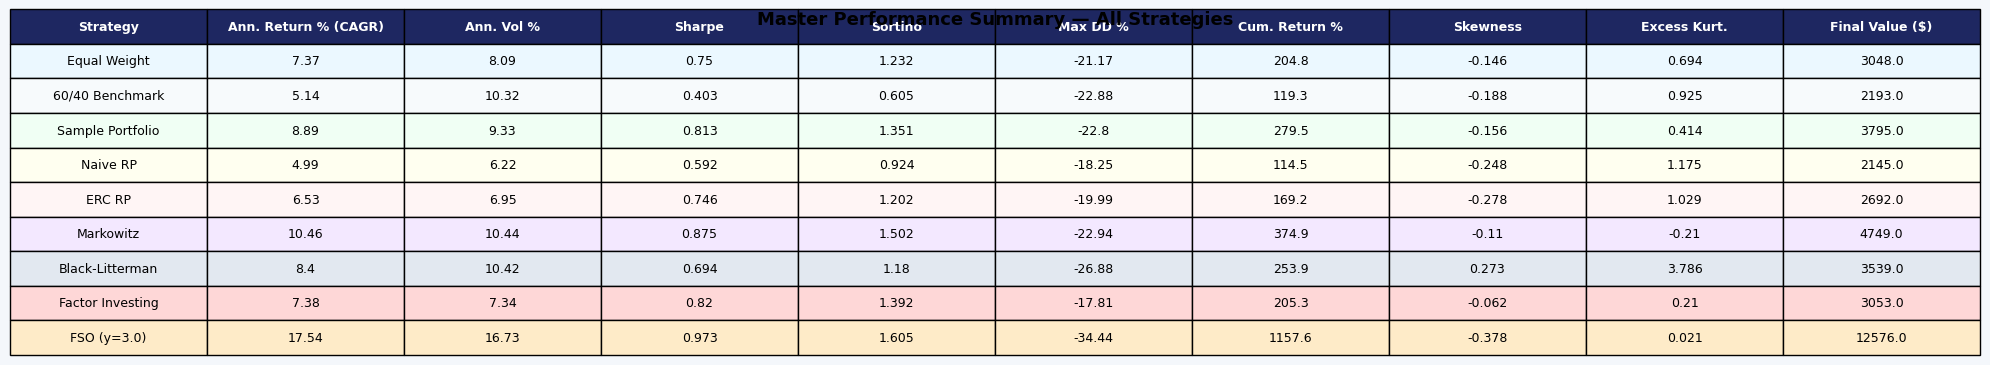

In [7]:
# ── Master performance table ─────────────────────────────────────────────────
summary = pd.DataFrame([
    compute_stats(ret, label, avg_rf_monthly, avg_rf_annual, initial_investment)
    for label, ret in sim.items()
])

print('=' * 80)
print('MASTER PERFORMANCE TABLE')
print('=' * 80)
print(summary.to_string())
print()
print('Note: Ann. Return is geometric CAGR. Sortino uses correct downside deviation.')
print(f'      FSO terminal value reflects optimizer concentration into VGT under γ=3.')

fig, ax = plt.subplots(figsize=(20, 3.8))
ax.axis('off')
col_labels = ['Strategy'] + list(summary.columns)
row_data   = [[idx] + [str(v) for v in summary.loc[idx]] for idx in summary.index]
tbl = ax.table(cellText=row_data, colLabels=col_labels, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.0, 2.2)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#1E2761')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
row_colors = ['#EBF8FF','#F7FAFC','#F0FFF4','#FFFFF0','#FFF5F5','#F3E8FF','#E2E8F0','#FED7D7','#FEEBC8']
for i, color in enumerate(row_colors, start=1):
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(color)
ax.set_title('Master Performance Summary — All Strategies', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()

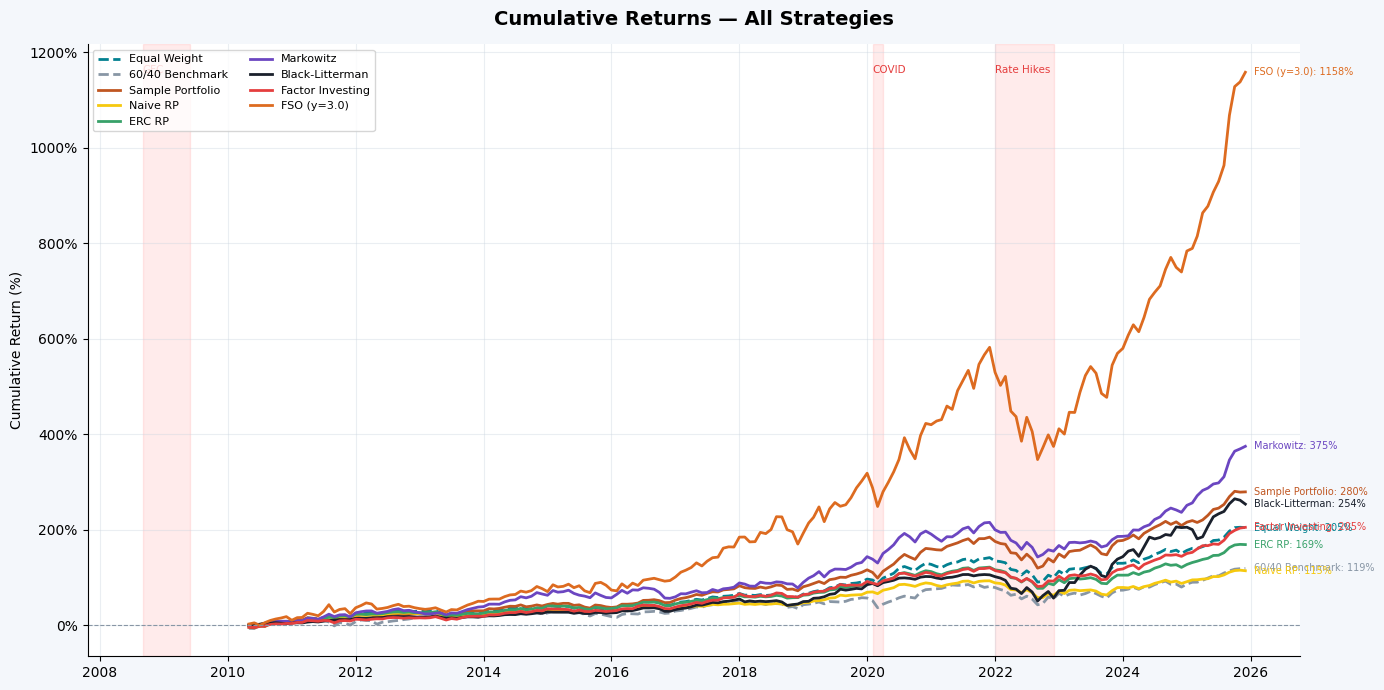

In [ ]:
# ── Cumulative returns ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
for label, ret in sim.items():
    cum = ((1 + ret).cumprod() - 1) * 100
    ls  = '--' if label in ('Equal Weight', '60/40 Benchmark') else '-'
    ax.plot(cum, label=label, color=PALETTE[label], linewidth=2, linestyle=ls)
    ax.annotate(
        f'{label}: {cum.iloc[-1]:.0f}%',
        xy=(cum.index[-1], cum.iloc[-1]), xytext=(6, 0),
        textcoords='offset points', fontsize=7, color=PALETTE[label], va='center',
    )
for s, e, lbl in CRISES:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color='red', zorder=0)
    ax.text(pd.Timestamp(s), ax.get_ylim()[1] * 0.95, lbl, fontsize=7.5, color='#E53E3E')
ax.axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Returns — All Strategies (2010 - 2025)', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Cumulative Return (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout(); plt.show()

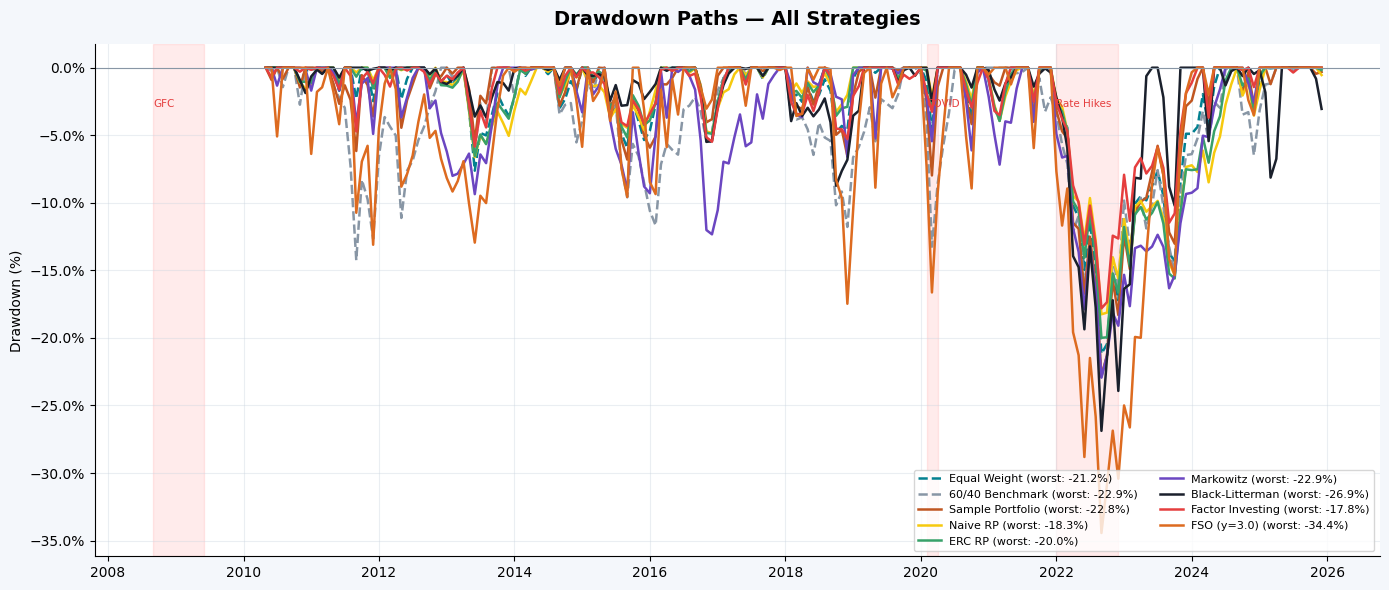

In [9]:
# ── Drawdown paths ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for label, ret in sim.items():
    cum = (1 + ret).cumprod()
    dd  = ((cum - cum.cummax()) / cum.cummax()) * 100
    ls  = '--' if label in ('Equal Weight', '60/40 Benchmark') else '-'
    ax.plot(
        dd,
        label=f'{label} (worst: {dd.min():.1f}%)',
        color=PALETTE[label], linewidth=1.8, linestyle=ls,
    )
for s, e, lbl in CRISES:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color='red', zorder=0)
    ax.text(pd.Timestamp(s), ax.get_ylim()[0] * 0.08, lbl, fontsize=7.5, color='#E53E3E')
ax.axhline(0, color='#8896A5', linewidth=0.8)
ax.set_title('Drawdown Paths — All Strategies', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=8, loc='lower right', ncol=2)
plt.tight_layout(); plt.show()

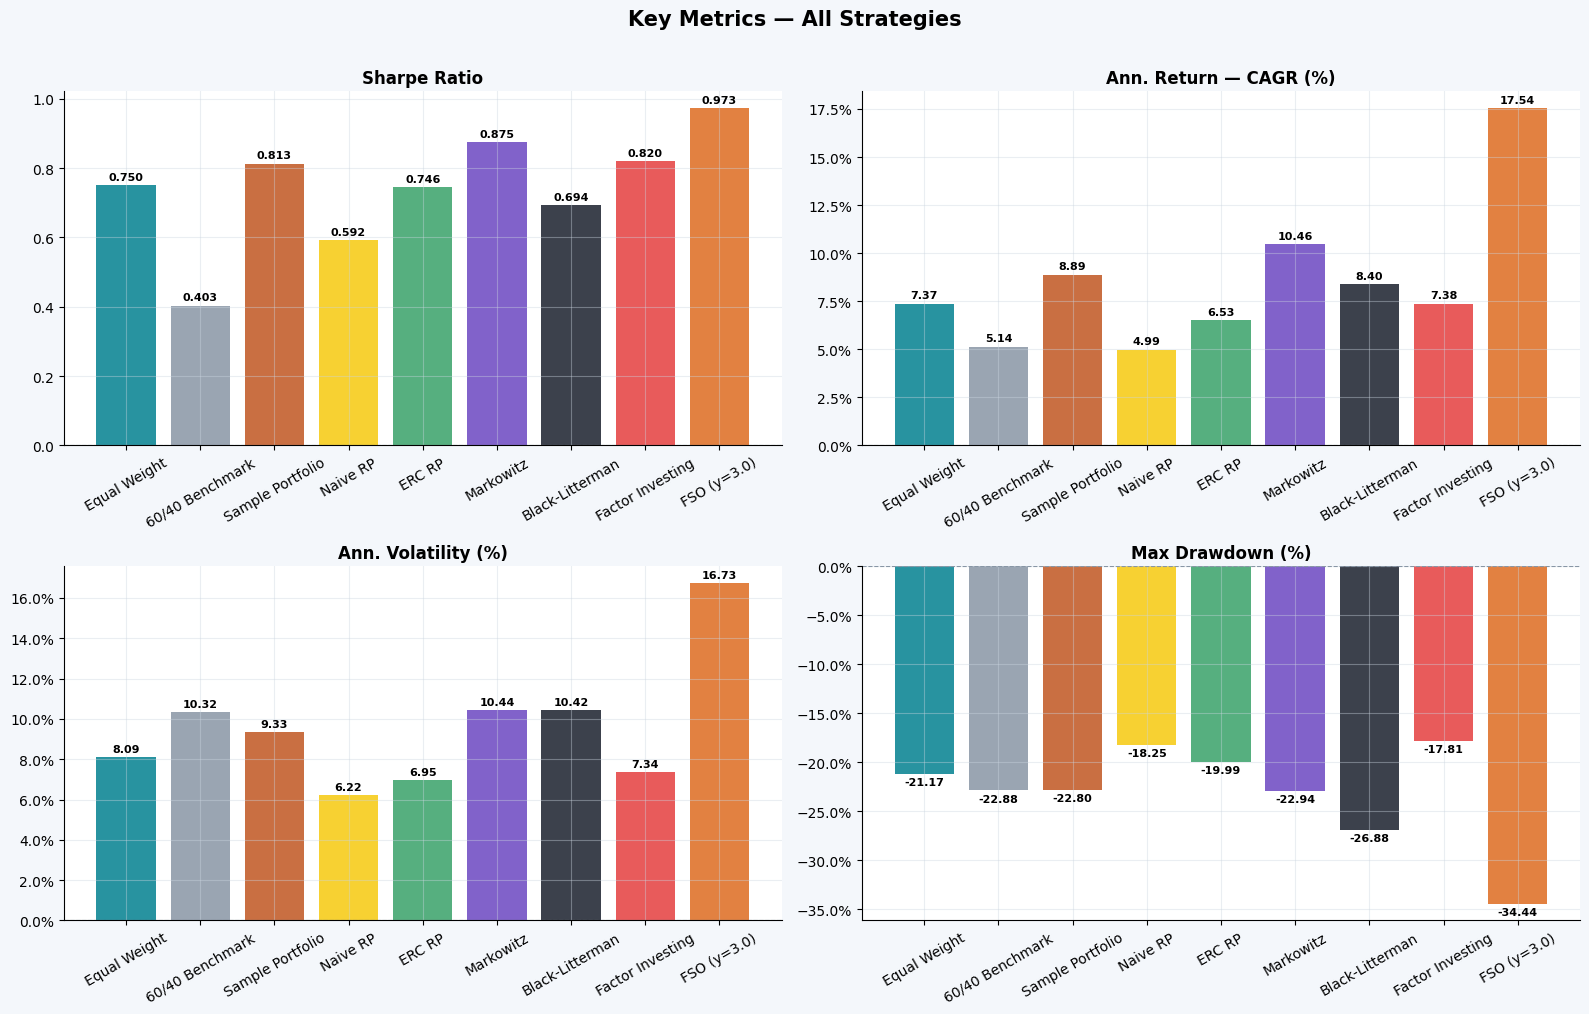

In [10]:
# ── Key metrics bar charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
labels_all = list(sim.keys())
colors_all = [PALETTE[l] for l in labels_all]

def bar_chart(ax, metric, title, fmt='{:.2f}', pct=False):
    vals = summary[metric]
    bars = ax.bar(vals.index, vals.values, color=colors_all, alpha=0.85)
    ax.axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
    for bar, v in zip(bars, vals.values):
        off = 0.01 * (vals.abs().max() or 1) * (1 if v >= 0 else -1)
        ax.text(
            bar.get_x() + bar.get_width() / 2, v + off, fmt.format(v),
            ha='center', va='bottom' if v >= 0 else 'top', fontsize=8, fontweight='bold',
        )
    ax.set_title(title, fontsize=12, fontweight='bold')
    if pct:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.tick_params(axis='x', rotation=30)

bar_chart(axes[0, 0], 'Sharpe',               'Sharpe Ratio',              '{:.3f}')
bar_chart(axes[0, 1], 'Ann. Return % (CAGR)',  'Ann. Return — CAGR (%)',    '{:.2f}', pct=True)
bar_chart(axes[1, 0], 'Ann. Vol %',            'Ann. Volatility (%)',       '{:.2f}', pct=True)
bar_chart(axes[1, 1], 'Max DD %',              'Max Drawdown (%)',          '{:.2f}', pct=True)

fig.suptitle('Key Metrics — All Strategies', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

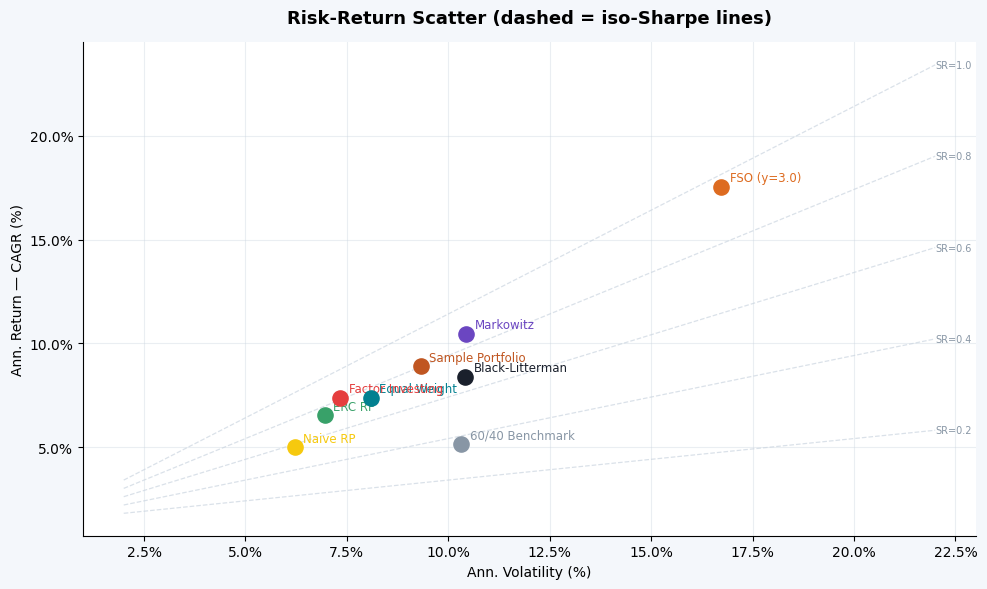

In [11]:
# ── Risk-return scatter with iso-Sharpe lines ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
vols_range = np.linspace(2, 22, 200)
for sr in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot(
        vols_range,
        avg_rf_annual * 100 + sr * vols_range,
        '--', color='#CBD5E0', linewidth=0.9, alpha=0.7,
    )
    ax.text(
        vols_range[-1], avg_rf_annual * 100 + sr * vols_range[-1],
        f'SR={sr:.1f}', fontsize=7, color='#8896A5', va='center',
    )
for label in sim:
    x = summary.loc[label, 'Ann. Vol %']
    y = summary.loc[label, 'Ann. Return % (CAGR)']
    ax.scatter(x, y, color=PALETTE[label], s=120, zorder=5)
    ax.annotate(label, (x, y), xytext=(6, 4), textcoords='offset points',
                fontsize=8.5, color=PALETTE[label])
ax.set_xlabel('Ann. Volatility (%)')
ax.set_ylabel('Ann. Return — CAGR (%)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Risk-Return Scatter (dashed = iso-Sharpe lines)', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(13, 8))  # wider and taller

# Iso-Sharpe lines — slightly more visible
vols_range = np.linspace(2, 22, 200)
for sr in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot(
        vols_range,
        avg_rf_annual * 100 + sr * vols_range,
        '--', color='#B0BEC5', linewidth=1.1, alpha=0.8,
    )
    ax.text(
        vols_range[-1], avg_rf_annual * 100 + sr * vols_range[-1],
        f'SR={sr:.1f}', fontsize=9, color='#607D8B', va='center',
    )

# Bigger dots, more breathing room
for label in sim:
    x = summary.loc[label, 'Ann. Vol %']
    y = summary.loc[label, 'Ann. Return % (CAGR)']
    ax.scatter(x, y, color=PALETTE[label], s=220, zorder=5,
               edgecolors='white', linewidths=1.2)  # white ring separates overlapping dots
    ax.annotate(label, (x, y), xytext=(9, 5), textcoords='offset points',
                fontsize=10, color=PALETTE[label], fontweight='bold')

# Cleaner axes
ax.set_xlabel('Ann. Volatility (%)', fontsize=12, labelpad=10)
ax.set_ylabel('Ann. Return — CAGR (%)', fontsize=12, labelpad=10)
ax.tick_params(labelsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, color='#CFD8DC')

ax.set_title('Risk-Return Scatter (dashed = iso-Sharpe lines)',
             fontsize=14, fontweight='bold', pad=18)

plt.tight_layout()
plt.show()

CRISIS RECOVERY TABLE (months from trough back to pre-crisis peak)
           Equal Weight 60/40 Benchmark Sample Portfolio Naive RP ERC RP Markowitz Black-Litterman Factor Investing FSO (y=3.0)
GFC                 N/A             N/A              N/A      N/A    N/A       N/A             N/A              N/A         N/A
COVID                1m              5m               2m       1m     1m        1m              1m               1m          3m
Rate Hikes          21m             23m              18m      24m    23m       22m              9m              17m         17m

N/A = never recovered within data period, or predates 36-month warm-up window.
GFC warm-up note: the 36-month lookback means strategy comparison starts May 2010,
after the GFC trough (Mar 2009), so GFC recovery cannot be measured for rolling strategies.


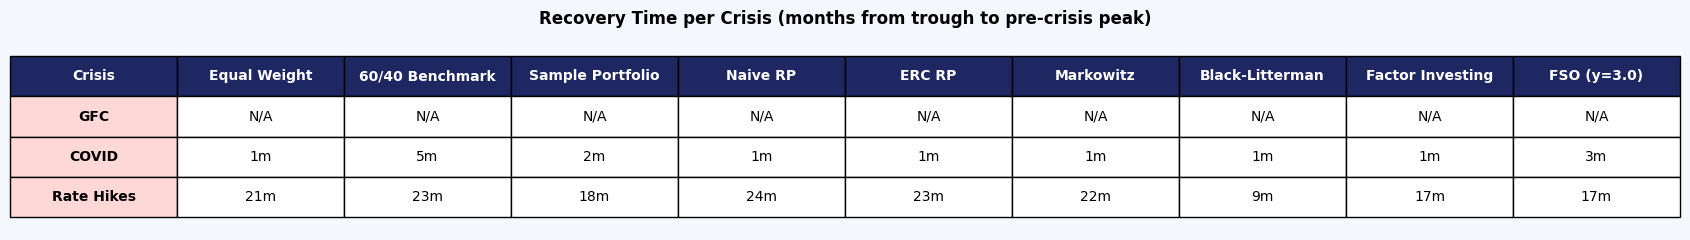

In [12]:
# ── Crisis recovery table ─────────────────────────────────────────────────────
print('=' * 80)
print('CRISIS RECOVERY TABLE (months from trough back to pre-crisis peak)')
print('=' * 80)

rec_data = {}
for cs, ce, cl in CRISES:
    rec_data[cl] = {}
    for lbl, ret in sim.items():
        m = months_to_recover(ret, cs, ce)      # called once per pair
        rec_data[cl][lbl] = 'N/A' if m is None else f'{m}m'

rec_df = pd.DataFrame(rec_data).T
print(rec_df.to_string())
print('\nN/A = never recovered within data period, or predates 36-month warm-up window.')
print('GFC warm-up note: the 36-month lookback means strategy comparison starts May 2010,')
print('after the GFC trough (Mar 2009), so GFC recovery cannot be measured for rolling strategies.')

fig, ax = plt.subplots(figsize=(17, 2.5))
ax.axis('off')
col_labels = ['Crisis'] + list(rec_df.columns)
row_data   = [[idx] + list(rec_df.loc[idx]) for idx in rec_df.index]
tbl = ax.table(cellText=row_data, colLabels=col_labels, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.0, 2.5)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#1E2761')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(rec_df) + 1):
    tbl[i, 0].set_facecolor('#FED7D7')
    tbl[i, 0].set_text_props(fontweight='bold')
ax.set_title(
    'Recovery Time per Crisis (months from trough to pre-crisis peak)',
    fontsize=12, fontweight='bold', pad=14,
)
plt.tight_layout(); plt.show()

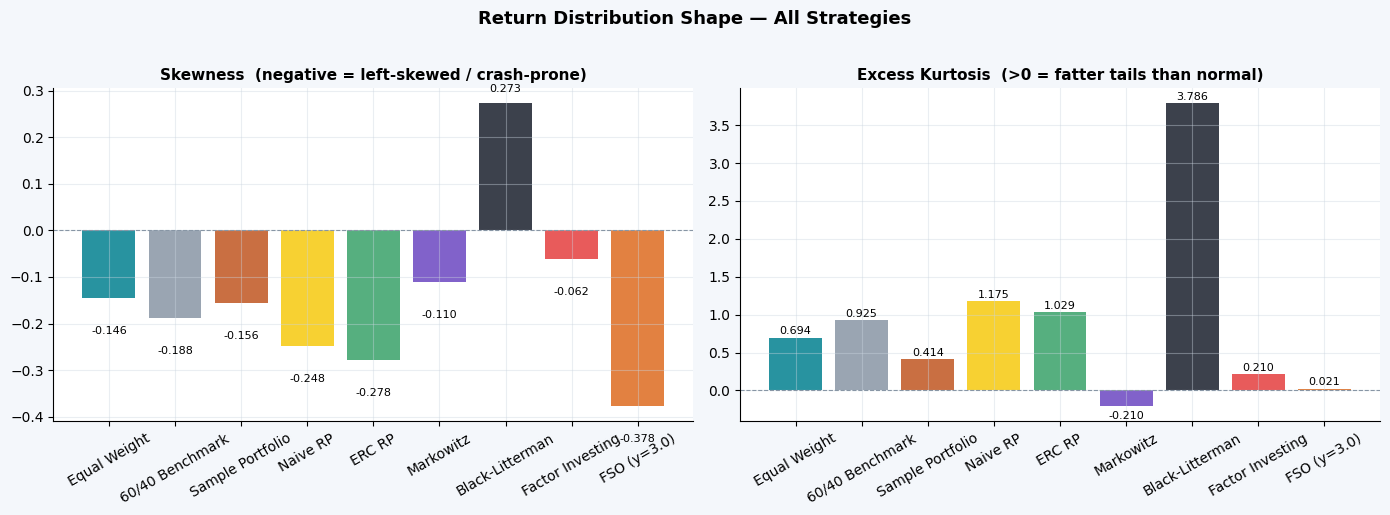


-- Distribution Statistics --
                  Skewness  Excess Kurt.
Equal Weight        -0.146         0.694
60/40 Benchmark     -0.188         0.925
Sample Portfolio    -0.156         0.414
Naive RP            -0.248         1.175
ERC RP              -0.278         1.029
Markowitz           -0.110        -0.210
Black-Litterman      0.273         3.786
Factor Investing    -0.062         0.210
FSO (y=3.0)         -0.378         0.021

Black-Litterman is the only strategy with positive skewness (+): asymmetric upside.
Naive RP shows the highest excess kurtosis: most fat-tailed monthly return distribution.


In [13]:
# ── Return distribution shape ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in [
    (axes[0], 'Skewness',     'Skewness  (negative = left-skewed / crash-prone)'),
    (axes[1], 'Excess Kurt.', 'Excess Kurtosis  (>0 = fatter tails than normal)'),
]:
    vals = summary[metric]
    cols = [PALETTE[l] for l in vals.index]
    bars = ax.bar(vals.index, vals.values, color=cols, alpha=0.85)
    ax.axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
    for bar, v in zip(bars, vals.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + (0.02 if v >= 0 else -0.06),
            f'{v:.3f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8,
        )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Return Distribution Shape — All Strategies', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\n-- Distribution Statistics --')
print(summary[['Skewness', 'Excess Kurt.']].to_string())
print('\nBlack-Litterman is the only strategy with positive skewness (+): asymmetric upside.')
print('Naive RP shows the highest excess kurtosis: most fat-tailed monthly return distribution.')

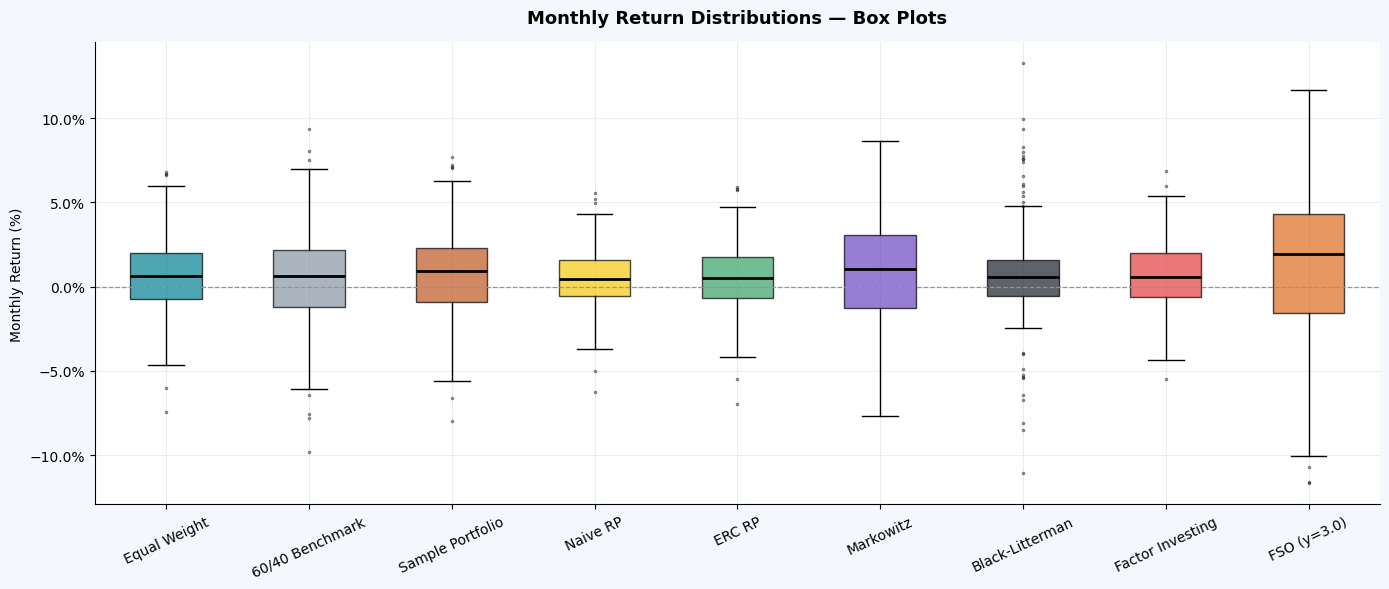

In [14]:
# ── Monthly return box plots ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(
    [sim[l].values * 100 for l in sim],
    labels=list(sim.keys()),
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='.', markersize=3, alpha=0.5),
)
for patch, lbl in zip(bp['boxes'], sim):
    patch.set_facecolor(PALETTE[lbl]); patch.set_alpha(0.7)
ax.axhline(0, color='#8896A5', linewidth=0.9, linestyle='--')
ax.set_title('Monthly Return Distributions — Box Plots', fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('Monthly Return (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

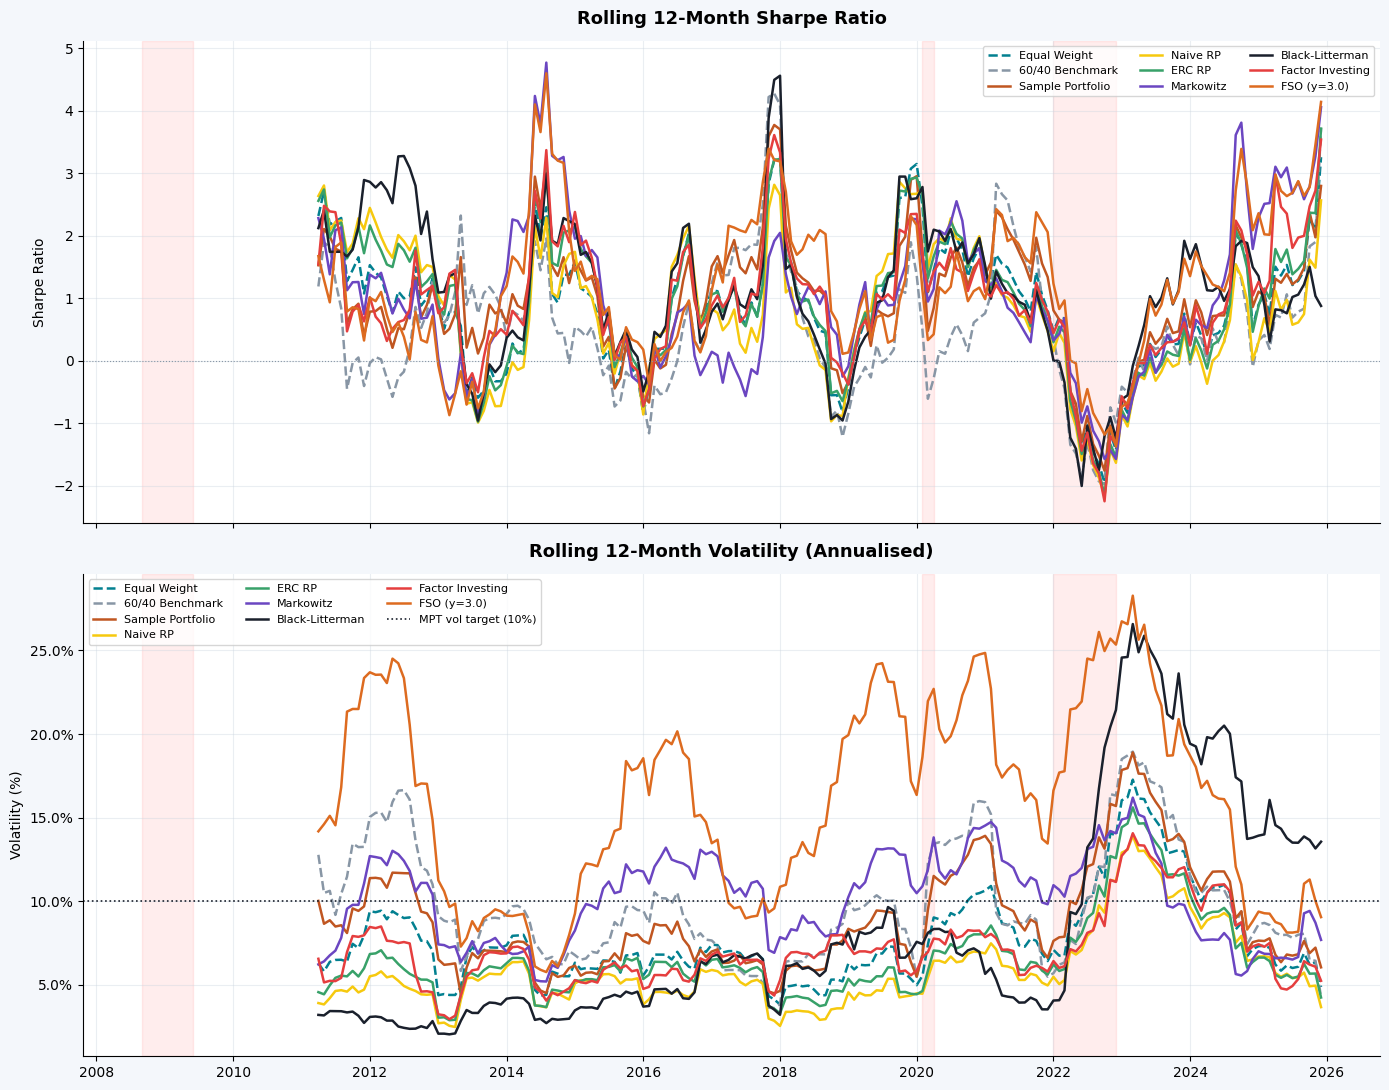

In [15]:
# ── Rolling Sharpe and volatility (12-month window) ───────────────────────────
ROLL_W = 12
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

for label, ret in sim.items():
    ls  = '--' if label in ('Equal Weight', '60/40 Benchmark') else '-'
    rm  = ret.rolling(ROLL_W).mean()
    rs  = ret.rolling(ROLL_W).std()
    rrf = monthly_rf_series.reindex(ret.index, method='ffill').rolling(ROLL_W).mean()
    rsr = (rm - rrf) * 12 / (rs * np.sqrt(12))
    axes[0].plot(rsr, label=label, color=PALETTE[label], linewidth=1.8, linestyle=ls)
    rv  = rs * np.sqrt(12) * 100
    axes[1].plot(rv,  label=label, color=PALETTE[label], linewidth=1.8, linestyle=ls)

axes[0].axhline(0, color='#8896A5', linewidth=0.8, linestyle=':')
axes[0].set_title(f'Rolling {ROLL_W}-Month Sharpe Ratio', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Sharpe Ratio')
axes[0].legend(fontsize=8, ncol=3)

axes[1].axhline(
    VOL_TARGET * 100, color='#1A202C', linewidth=1.2, linestyle=':',
    label=f'MPT vol target ({VOL_TARGET*100:.0f}%)',
)
axes[1].set_title(f'Rolling {ROLL_W}-Month Volatility (Annualised)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Volatility (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(fontsize=8, ncol=3)

for ax in axes:
    for s, e, lbl in CRISES:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.07, color='red', zorder=0)

plt.tight_layout(); plt.show()

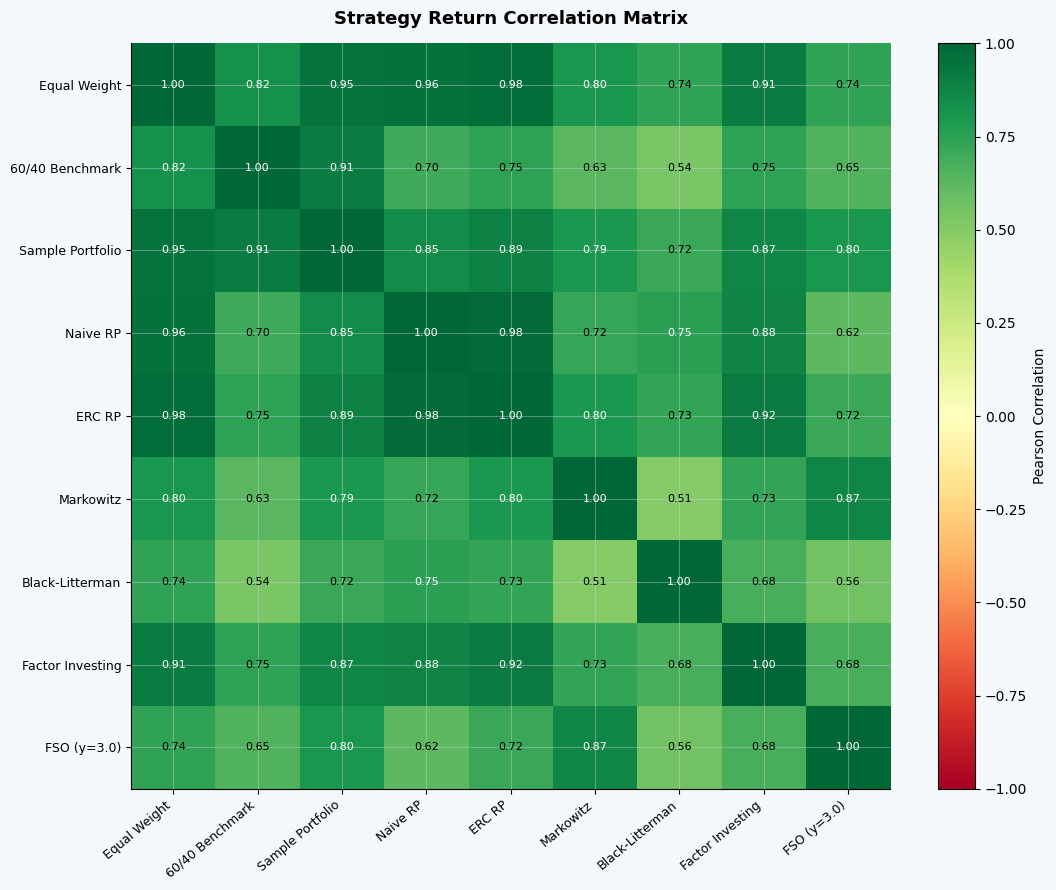

High correlation = strategies behave similarly despite different algorithms (BHB thesis).
Low correlation  = strategies provide genuinely different exposures.


In [16]:
# ── Strategy return correlation matrix ────────────────────────────────────────
ret_df  = pd.DataFrame(sim)
corr_df = ret_df.corr()
n_s     = len(sim)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_df.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_xticks(range(n_s)); ax.set_yticks(range(n_s))
ax.set_xticklabels(corr_df.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(corr_df.index, fontsize=9)
for i in range(n_s):
    for j in range(n_s):
        v = corr_df.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(v) > 0.75 else 'black')
ax.set_title('Strategy Return Correlation Matrix', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()
print('High correlation = strategies behave similarly despite different algorithms (BHB thesis).')
print('Low correlation  = strategies provide genuinely different exposures.')

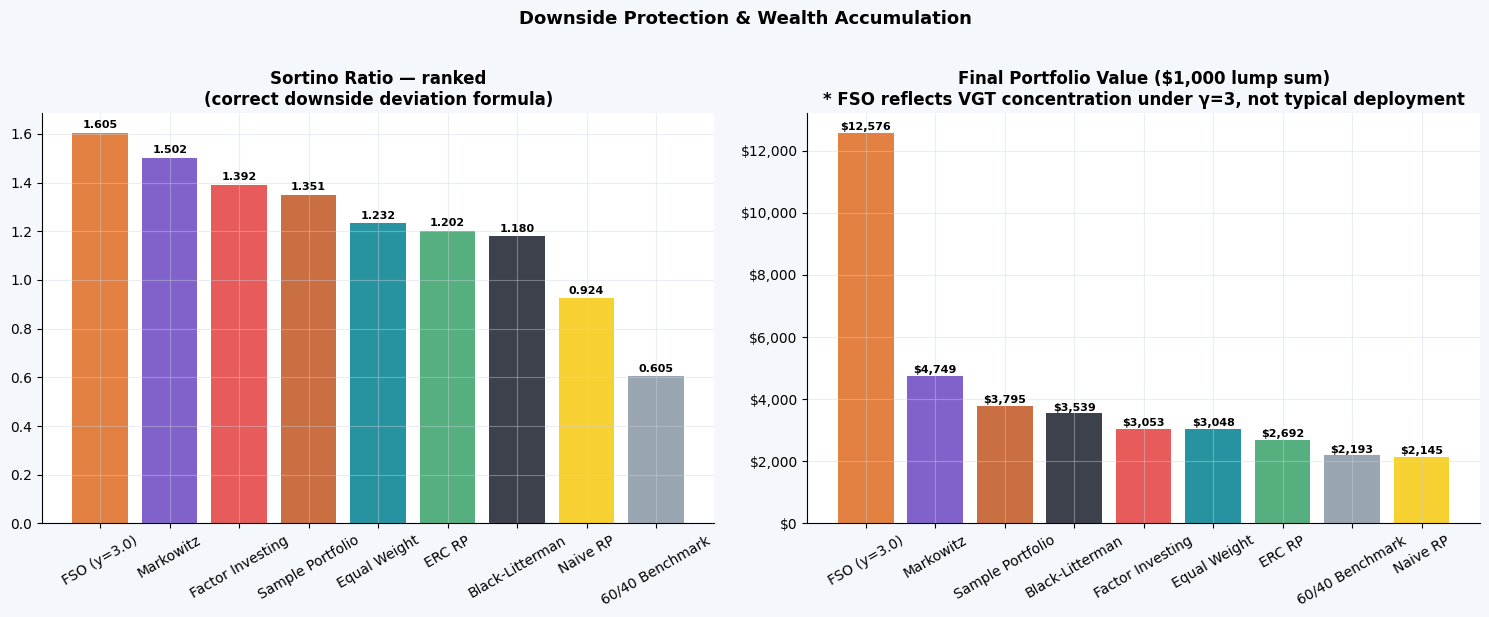

In [17]:
# ── Sortino and final value bar charts ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

so_vals = summary['Sortino'].sort_values(ascending=False)
c_so    = [PALETTE[l] for l in so_vals.index]
bars = axes[0].bar(so_vals.index, so_vals.values, color=c_so, alpha=0.85)
for bar, v in zip(bars, so_vals.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
axes[0].set_title('Sortino Ratio — ranked\n(correct downside deviation formula)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

fv_vals = summary['Final Value ($)'].sort_values(ascending=False)
c_fv    = [PALETTE[l] for l in fv_vals.index]
bars2 = axes[1].bar(fv_vals.index, fv_vals.values, color=c_fv, alpha=0.85)
for bar, v in zip(bars2, fv_vals.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 20,
                 f'${v:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_title(
    f'Final Portfolio Value (${initial_investment:,.0f} lump sum)\n'
    '* FSO reflects VGT concentration under γ=3, not typical deployment',
    fontsize=12, fontweight='bold',
)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Downside Protection & Wealth Accumulation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

STRATEGY RANKING  (1 = best per metric, sorted by average rank)
                  Return  Vol  Sharpe  Sortino  Max DD  Avg Rank
Factor Investing       5    3       3        3       1       3.0
Sample Portfolio       3    5       4        4       5       4.2
Markowitz              2    8       2        2       7       4.2
FSO (y=3.0)            1    9       1        1       9       4.2
ERC RP                 7    2       6        6       3       4.8
Equal Weight           6    4       5        5       4       4.8
Naive RP               9    1       8        8       2       5.6
Black-Litterman        4    7       7        7       8       6.6
60/40 Benchmark        8    6       9        9       6       7.6

Overall winner: Factor Investing  (avg rank 3.0)


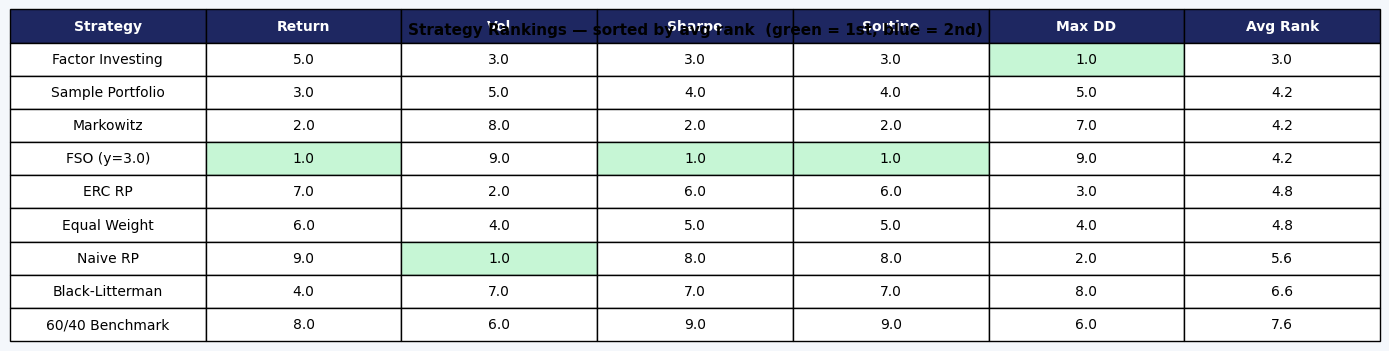

In [18]:
# ── Overall strategy ranking ──────────────────────────────────────────────────
# Ranking logic:
#   Return  : rank(ascending=False) → rank 1 = highest CAGR
#   Vol     : rank(ascending=True)  → rank 1 = lowest volatility
#   Sharpe  : rank(ascending=False) → rank 1 = highest Sharpe
#   Sortino : rank(ascending=False) → rank 1 = highest Sortino
#   Max DD  : rank(ascending=False) → rank 1 = least negative (best protection)
#             Max DD values are negative; -17.90 > -34.44 so ascending=False
#             correctly assigns rank 1 to the least severe drawdown.

rank_df = pd.DataFrame(index=summary.index)
rank_df['Return']   = summary['Ann. Return % (CAGR)'].rank(ascending=False).astype(int)
rank_df['Vol']      = summary['Ann. Vol %'].rank(ascending=True).astype(int)
rank_df['Sharpe']   = summary['Sharpe'].rank(ascending=False).astype(int)
rank_df['Sortino']  = summary['Sortino'].rank(ascending=False).astype(int)
rank_df['Max DD']   = summary['Max DD %'].rank(ascending=False).astype(int)
rank_df['Avg Rank'] = rank_df.mean(axis=1).round(1)
rank_df = rank_df.sort_values('Avg Rank')

print('=' * 70)
print('STRATEGY RANKING  (1 = best per metric, sorted by average rank)')
print('=' * 70)
print(rank_df.to_string())
print(f"\nOverall winner: {rank_df.index[0]}  (avg rank {rank_df.iloc[0]['Avg Rank']})")

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.axis('off')
col_labels = ['Strategy'] + list(rank_df.columns)
row_data   = [[idx] + list(rank_df.loc[idx]) for idx in rank_df.index]
tbl = ax.table(cellText=row_data, colLabels=col_labels, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.0, 2.4)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#1E2761')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i, idx in enumerate(rank_df.index, start=1):
    for j, col in enumerate(rank_df.columns, start=1):
        v = rank_df.loc[idx, col]
        if v == 1:
            tbl[i, j].set_facecolor('#C6F6D5')
        elif isinstance(v, (int, float)) and v <= 2:
            tbl[i, j].set_facecolor('#EBF8FF')
ax.set_title(
    'Strategy Rankings — sorted by avg rank  (green = 1st, blue = 2nd)',
    fontsize=11, fontweight='bold', pad=14,
)
plt.tight_layout(); plt.show()